In [95]:
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import yaml
import os.path as op
import scanpy as sc
import numpy as np
import pandas as pd




In [96]:



def read_all_results_sweep(root_dir, select = ('overlaps_global_top_k.tsv')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(select) :
                filepath = os.path.join(dirpath, filename)
                try:
                    overlaps = pd.read_csv(filepath, sep = '\t', index_col=0)
                    overlaps['algorithm'] = op.basename(op.dirname(op.dirname(op.dirname(filepath))))
                    overlaps['config'] = op.basename(op.dirname(op.dirname(filepath)))
                    overlaps['dataset'] = op.basename(op.dirname(filepath))
                    overlaps['method']  = op.basename(filepath).replace(select, '')
                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results


In [97]:

outdir ='/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/summaries_final_benchmark'
os.makedirs(outdir, exist_ok=True)

final_metrics = read_all_results_sweep('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/',   select = ('_aggregated_performance.tsv'))
split_data = final_metrics['method'].str.split('_', expand=True)
split_data.columns = ['xai_method', 'hidden_layer_size', 'n_hidden_layers', 'dropout', 'model', 'background', 'raw']
final_metrics = pd.concat([final_metrics, split_data], axis=1)
final_metrics  = final_metrics.drop(columns= ['n_top'])
final_metrics = final_metrics.rename(columns= {'top_perc': "n_top", 'percentage_recovered': 'percentage_overlap',  'type': 'target'})
final_metrics.to_csv(op.join(outdir, 'edge_recovery_best_netmap_grn.tsv'), sep = '\t', index = False)

In [98]:


def read_all_results_grnboost(root_dir, select = ('overlaps_global_top_k_quantile_count.tsv')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(select) :

                filepath = os.path.join(dirpath, filename)
                print(filepath)
                try:
                    overlaps = pd.read_csv(filepath, sep = '\t', index_col=0)
                    overlaps['algorithm'] = op.basename(op.dirname(op.dirname(op.dirname(op.dirname(op.dirname(filepath))))))
                    overlaps['config'] = op.basename(op.dirname(op.dirname(filepath)))
                    overlaps['dataset'] = op.basename(op.dirname(filepath))


                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results

In [99]:
grnb = read_all_results_grnboost('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/',   select = 'preclustered_overlaps_global_top_k.tsv')
grnb['top_perc'] = np.tile([0.001,0.01, 0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 1.0], reps = int(grnb.shape[0]/9))
grnb  = grnb.drop(columns= ['n_top'])
grnb = grnb.rename(columns= {'top_perc': "n_top", 'percentage_recovered': 'percentage_overlap',  'type': 'target'})

grnb.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/edge_recovery_grnboost.tsv', sep = '\t', index=False)


/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2/config_easy/net_133_10773_net_82_10152_net_72_10551/config_easy/net_133_10773_net_82_10152_net_72_10551/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2/config_easy/net_172_10626_net_89_11634_net_76_10367/config_easy/net_172_10626_net_89_11634_net_76_10367/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2/config_easy/net_53_11196_net_70_11431_net_84_9903/config_easy/net_53_11196_net_70_11431_net_84_9903/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2/config_easy/net_59_10488_net_115_11153_net_84_11226/config_easy/net_59_10488_net_115_11153_net_84_11226/preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/gr

In [100]:
grnb

,percentage_overlap,tp,gs_count,pp,target,grn,net,algorithm,config,dataset,n_top
0,0.009950,2,201,55,on_target,0,0,grnboost2,config_easy,net_133_10773_net_82_10152_net_72_10551,0.001
1,0.029851,6,201,547,on_target,0,0,grnboost2,config_easy,net_133_10773_net_82_10152_net_72_10551,0.010
2,0.089552,18,201,2736,on_target,0,0,grnboost2,config_easy,net_133_10773_net_82_10152_net_72_10551,0.050
3,0.174129,35,201,5472,on_target,0,0,grnboost2,config_easy,net_133_10773_net_82_10152_net_72_10551,0.100
4,0.293532,59,201,10943,on_target,0,0,grnboost2,config_easy,net_133_10773_net_82_10152_net_72_10551,0.200
...,...,...,...,...,...,...,...,...,...,...,...
4,0.628571,88,140,82898,on_target,9,9,grnboost2,config_ten,net_89_11634_net_85_11467_net_133_10773_net_99...,0.200
5,0.628571,88,140,82898,on_target,9,9,grnboost2,config_ten,net_89_11634_net_85_11467_net_133_10773_net_99...,0.250
6,0.628571,88,140,82898,on_target,9,9,grnboost2,config_ten,net_89_11634_net_85_11467_net_133_10773_net_99...,0.500
7,0.628571,88,140,82898,on_target,9,9,grnboost2,config_ten,net_89_11634_net_85_11467_net_133_10773_net_99...,0.750


In [101]:
final_metrics = pd.concat([final_metrics, grnb])

In [102]:
final_metrics.iloc[100:120]

,percentage_overlap,tp,gs_count,pp,target,grn,net,n_top,algorithm,config,dataset,method,xai_method,hidden_layer_size,n_hidden_layers,dropout,model,background,raw
12,0.598326,143,239,62463,on_target,net_172_10626,0,0.550,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False
13,0.656904,157,239,68141,on_target,net_172_10626,0,0.600,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False
14,0.719665,172,239,73820,on_target,net_172_10626,0,0.650,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False
15,0.736402,176,239,79498,on_target,net_172_10626,0,0.700,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False
16,0.782427,187,239,85177,on_target,net_172_10626,0,0.750,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False
17,0.807531,193,239,90855,on_target,net_172_10626,0,0.800,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False
18,0.849372,203,239,96534,on_target,net_172_10626,0,0.850,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False
19,0.895397,214,239,102212,on_target,net_172_10626,0,0.900,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False
20,0.933054,223,239,107891,on_target,net_172_10626,0,0.950,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False
21,1.000000,239,239,113569,on_target,net_172_10626,0,1.000,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap,64,1,0.1,NegativeBinomialAutoencoder,zeros,False


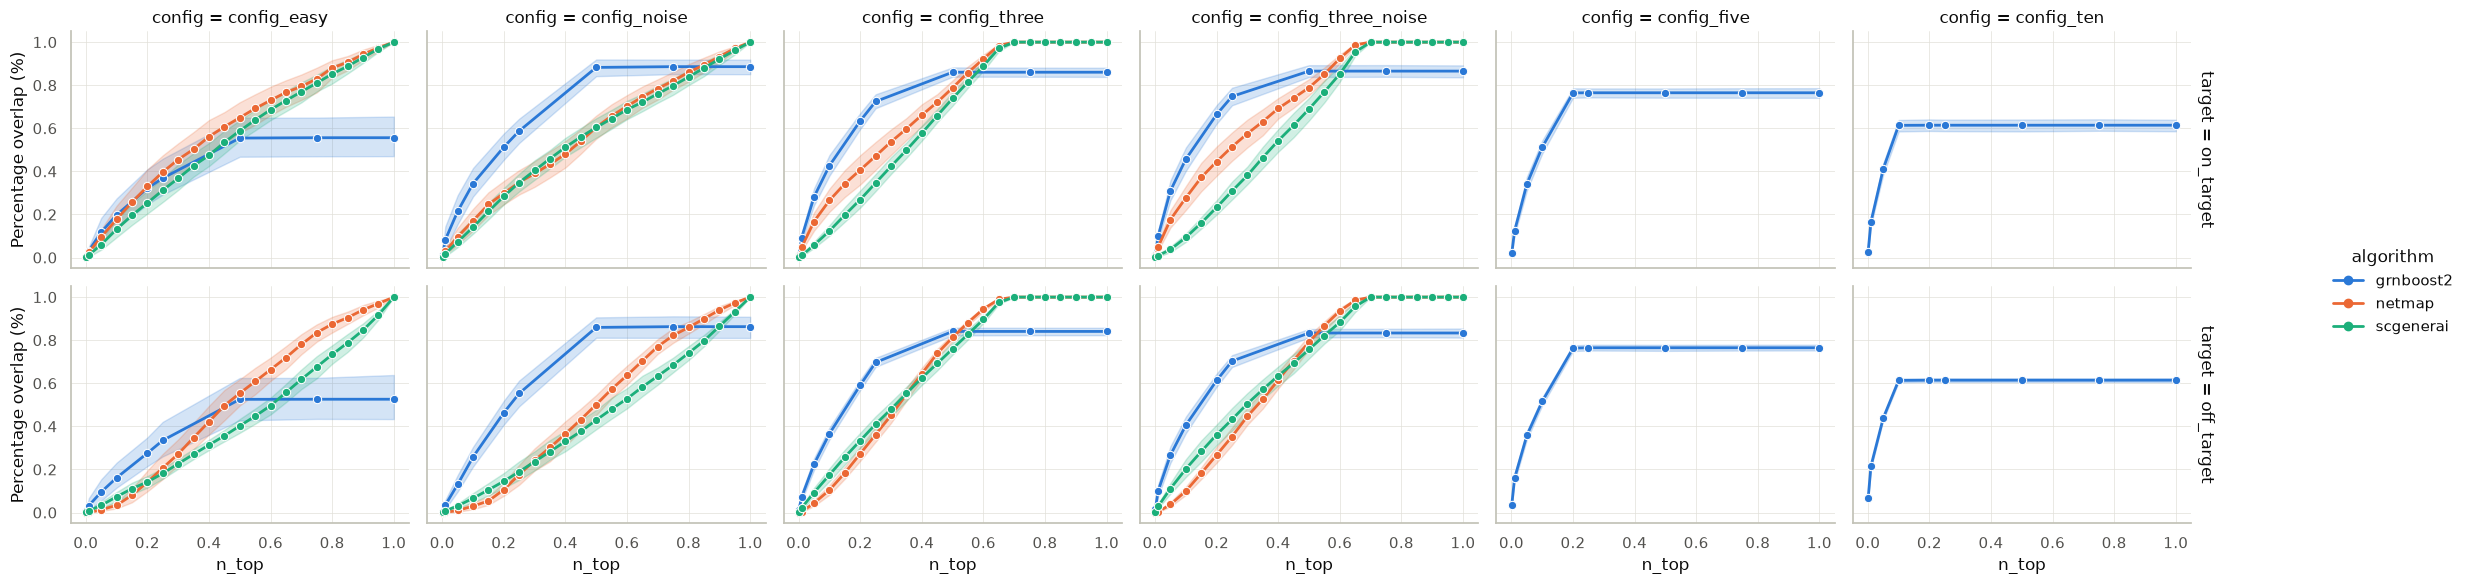

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fixed categorical order — do not let seaborn auto-cycle colors.
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#c3c2b7",
    "grid.color": "#e1e0d9",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})

algorithms = sorted(final_metrics["algorithm"].unique())
palette = dict(zip(algorithms, CATEGORICAL_PALETTE))

g = sns.relplot(
    data=final_metrics,
    x="n_top",
    y="percentage_overlap",
    hue="algorithm",
    hue_order=algorithms,
    palette=palette,
    row="target",
    col="config",
    kind="line",
    marker="o",
    linewidth=2,
    markersize=6,
    facet_kws={"margin_titles": True},
    height=3,
    aspect=1.3,
)

g.set_axis_labels("n_top", "Percentage overlap (%)")
g.set_titles(row_template="target = {row_name}", col_template="config = {col_name}")
g.tight_layout()

for ax in g.axes.flat:
    ax.grid(True, axis="both", linewidth=0.5)
    sns.despine(ax=ax, left=False, bottom=False)

#plt.savefig("overlap_by_ntop.png", dpi=200, bbox_inches="tight")
plt.show()
